In [3]:


import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/josephsudheer0506
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Healthy
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Hypersensitivity
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Fungal_infections
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/ringworm
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Healthy
/kaggle/input/datasets/josephsudhe

In [4]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [5]:
import os

dataset_path = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/train"

total = 0

print("-"*45)
print("{:<25} {:>10}".format("Class", "Images"))
print("-"*45)

for cls in sorted(os.listdir(dataset_path)):
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        total += count
        print("{:<25} {:>10}".format(cls, count))

print("-"*45)
print("{:<25} {:>10}".format("TOTAL", total))

---------------------------------------------
Class                         Images
---------------------------------------------
Dermatitis                       546
Fungal_infections                375
Healthy                          492
Hypersensitivity                 230
demodicosis                      588
ringworm                         791
---------------------------------------------
TOTAL                           3022


In [43]:
from sklearn.metrics import classification_report

predictions_mob = mobilenet_model.predict(test_data)
y_pred_mob = np.argmax(predictions_mob, axis=1)

print(classification_report(
    test_data.classes,
    y_pred_mob,
    target_names=list(test_data.class_indices.keys())
))

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 582ms/step
                   precision    recall  f1-score   support

       Dermatitis       0.09      0.06      0.07        66
Fungal_infections       0.07      0.09      0.08        54
          Healthy       0.13      0.55      0.21        69
 Hypersensitivity       0.00      0.00      0.00        29
      demodicosis       0.12      0.02      0.03       100
         ringworm       0.00      0.00      0.00       115

         accuracy                           0.11       433
        macro avg       0.07      0.12      0.07       433
     weighted avg       0.07      0.11      0.06       433



In [7]:
import tensorflow as tf
import sys

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)

2026-07-08 19:19:10.816208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783538351.044472      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783538351.111159      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783538351.658475      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783538351.658530      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783538351.658533      58 computation_placer.cc:177] computation placer alr

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.19.0


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [9]:
train_dir = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/train"

valid_dir = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid"

test_dir = "/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test"

print("Paths Set Successfully")

Paths Set Successfully


In [10]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/josephsudheer0506
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Healthy
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Hypersensitivity
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Fungal_infections
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/ringworm
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Healthy
/kaggle/input/datasets/josephsudhe

In [11]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [12]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_data = test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_data.class_indices)

Found 3022 images belonging to 6 classes.
Found 860 images belonging to 6 classes.
Found 433 images belonging to 6 classes.
{'Dermatitis': 0, 'Fungal_infections': 1, 'Healthy': 2, 'Hypersensitivity': 3, 'demodicosis': 4, 'ringworm': 5}


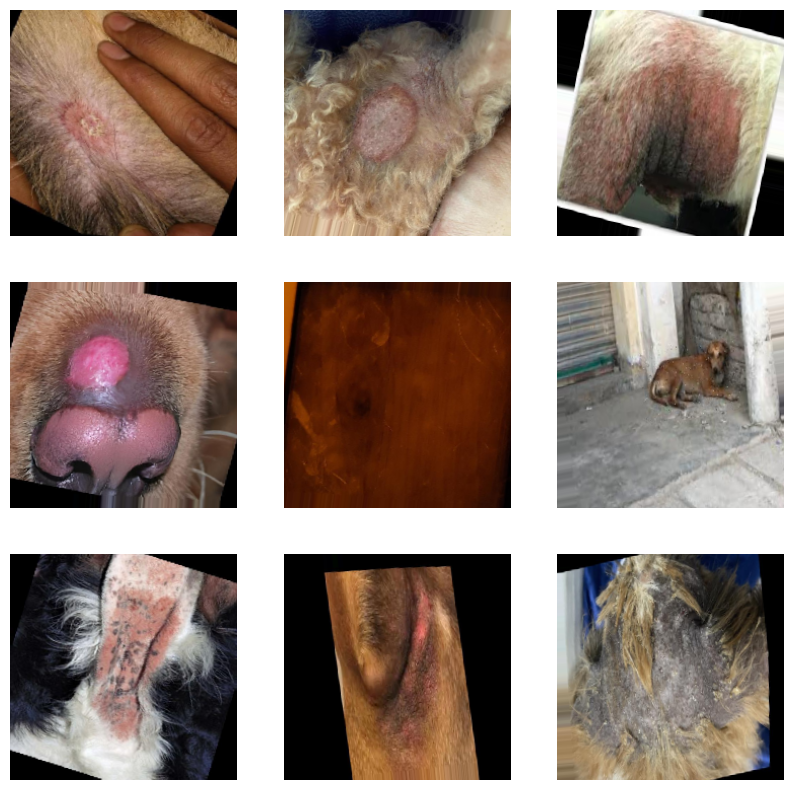

In [13]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

In [14]:
cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(6,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-08 19:20:00.044498: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.3048 - loss: 1.6802 - val_accuracy: 0.3849 - val_loss: 1.5186
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.4007 - loss: 1.4999 - val_accuracy: 0.4047 - val_loss: 1.5371
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.4027 - loss: 1.4600 - val_accuracy: 0.4279 - val_loss: 1.3831
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.4500 - loss: 1.3769 - val_accuracy: 0.5128 - val_loss: 1.3106
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.4921 - loss: 1.3108 - val_accuracy: 0.4488 - val_loss: 1.3019
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.5089 - loss: 1.2730 - val_accuracy: 0.5744 - val_loss: 1.1265
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.5281 - loss: 1.2103 - val_accuracy: 0.5756 - val_loss: 1.1491
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.5804 - loss: 1.1097 - val_accuracy: 0.6267 - v

In [21]:
import time
import numpy as np

test_data.reset()

start = time.time()

predictions = mobilenet_model.predict(test_data, verbose=0)

end = time.time()

total_time = end - start
per_image = total_time / test_data.samples

print("Total inference time:", total_time, "seconds")
print("Inference time per image:", per_image*1000, "ms")

NameError: name 'mobilenet_model' is not defined

In [20]:
start = time.time()

predictions = cnn_model.predict(test_data, verbose=0)

end = time.time()

print("Total inference time:", end-start)
print("Inference per image:", ((end-start)/test_data.samples)*1000, "ms")

Total inference time: 7.202118158340454
Inference per image: 16.633067340278185 ms


In [22]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/josephsudheer0506
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Healthy
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Hypersensitivity
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/Fungal_infections
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/valid/ringworm
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Dermatitis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/demodicosis
/kaggle/input/datasets/josephsudheer0506/dogs-skin-diseases/test/Healthy
/kaggle/input/datasets/josephsudhe

In [23]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


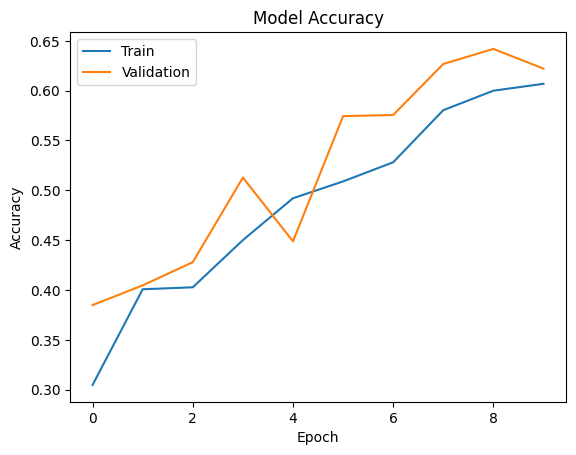

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.savefig('accuracy_curve.png')
plt.show()

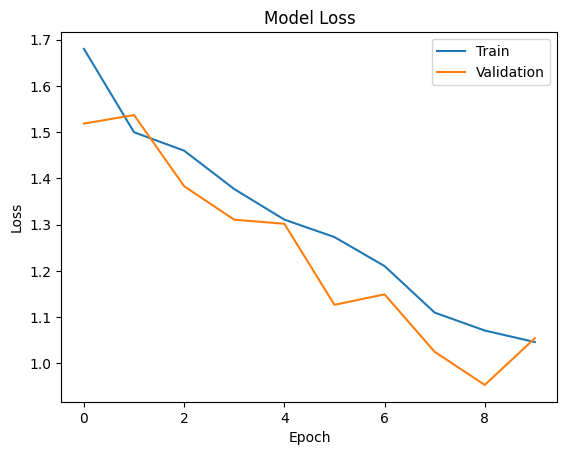

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.savefig('loss_curve.png')
plt.show()

In [26]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(6, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input,
                        outputs=predictions)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 2,388,614 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [27]:
import numpy as np

predictions = cnn_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 443ms/step


In [28]:
history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 374s 4s/step - accuracy: 0.6794 - loss: 0.8929 - val_accuracy: 0.2465 - val_loss: 16.1592
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 350s 4s/step - accuracy: 0.7856 - loss: 0.6014 - val_accuracy: 0.2465 - val_loss: 19.0865
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 355s 4s/step - accuracy: 0.8074 - loss: 0.5322 - val_accuracy: 0.2465 - val_loss: 17.4530
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 349s 4s/step - accuracy: 0.8537 - loss: 0.4096 - val_accuracy: 0.2488 - val_loss: 11.3624
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.8544 - loss: 0.4197 - val_accuracy: 0.2465 - val_loss: 14.3256
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.8733 - loss: 0.3726 - val_accuracy: 0.2465 - val_loss: 13.6055
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 337s 4s/step - accuracy: 0.8872 - loss: 0.3230 - val_accuracy: 0.2477 - val_loss: 14.4057
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.9017 - loss: 0.3008 - val_accuracy: 0.2

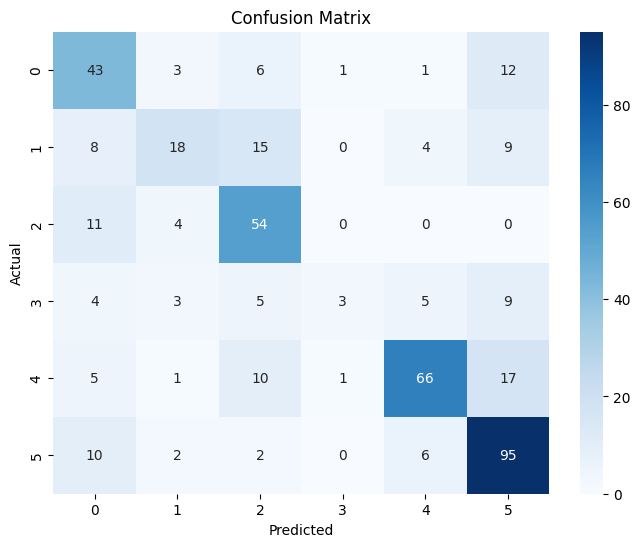

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()

In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_data.classes,
        y_pred,
        target_names=list(test_data.class_indices.keys())
    )
)

                   precision    recall  f1-score   support

       Dermatitis       0.53      0.65      0.59        66
Fungal_infections       0.58      0.33      0.42        54
          Healthy       0.59      0.78      0.67        69
 Hypersensitivity       0.60      0.10      0.18        29
      demodicosis       0.80      0.66      0.73       100
         ringworm       0.67      0.83      0.74       115

         accuracy                           0.64       433
        macro avg       0.63      0.56      0.55       433
     weighted avg       0.65      0.64      0.62       433



In [42]:
cnn_model.save("livestock_skin_disease_model.h5")

In [32]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(6, activation='softmax')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", test_accuracy)
print("MobileNetV2 Test Loss:", test_loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 584ms/step - accuracy: 0.1132 - loss: 2.2970
MobileNetV2 Test Accuracy: 0.11316397041082382
MobileNetV2 Test Loss: 2.2970163822174072


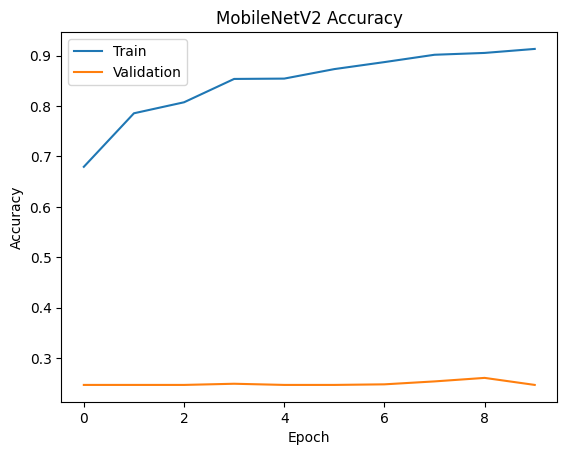

In [34]:
import matplotlib.pyplot as plt

plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.savefig('mobilenet_accuracy.png')
plt.show()

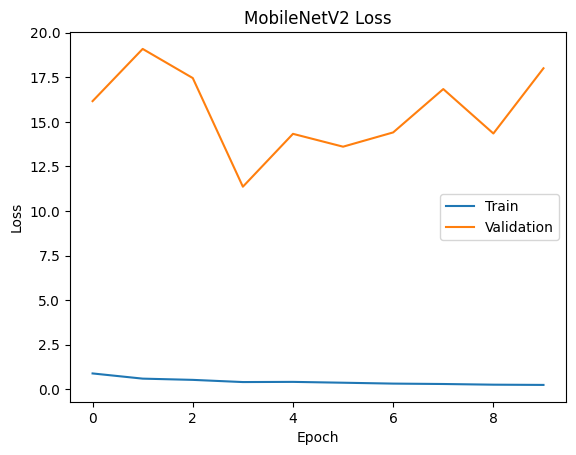

In [35]:
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.savefig('mobilenet_loss.png')
plt.show()

In [36]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", test_accuracy)
print("MobileNetV2 Test Loss:", test_loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 580ms/step - accuracy: 0.1132 - loss: 2.2970
MobileNetV2 Test Accuracy: 0.11316397041082382
MobileNetV2 Test Loss: 2.2970163822174072


In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = mobilenet_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    test_data.classes,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 673ms/step
                   precision    recall  f1-score   support

       Dermatitis       0.09      0.06      0.07        66
Fungal_infections       0.07      0.09      0.08        54
          Healthy       0.13      0.55      0.21        69
 Hypersensitivity       0.00      0.00      0.00        29
      demodicosis       0.12      0.02      0.03       100
         ringworm       0.00      0.00      0.00       115

         accuracy                           0.11       433
        macro avg       0.07      0.12      0.07       433
     weighted avg       0.07      0.11      0.06       433



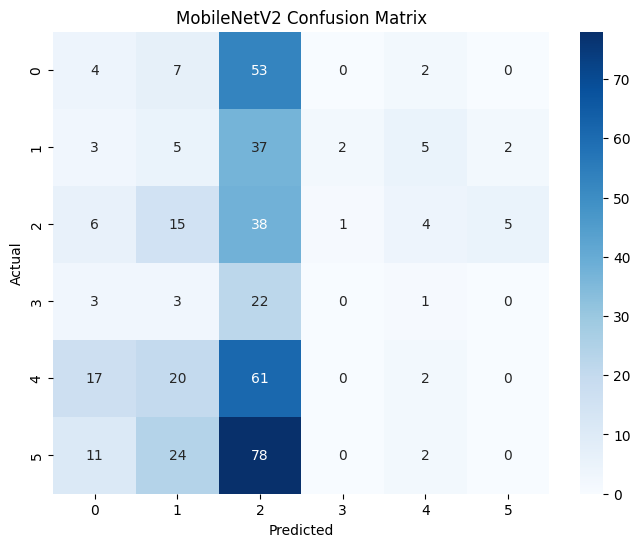

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("mobilenet_confusion_matrix.png")
plt.show()

In [39]:
for layer in base_model.layers:
    layer.trainable = False

In [76]:
from sklearn.metrics import classification_report

predictions_mob = mobilenet_model.predict(test_data)
y_pred_mob = np.argmax(predictions_mob, axis=1)

print(classification_report(
    test_data.classes,
    y_pred_mob,
    target_names=list(test_data.class_indices.keys())
))

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 548ms/step
                   precision    recall  f1-score   support

       Dermatitis       0.09      0.06      0.07        66
Fungal_infections       0.07      0.09      0.08        54
          Healthy       0.13      0.55      0.21        69
 Hypersensitivity       0.00      0.00      0.00        29
      demodicosis       0.12      0.02      0.03       100
         ringworm       0.00      0.00      0.00       115

         accuracy                           0.11       433
        macro avg       0.07      0.12      0.07       433
     weighted avg       0.07      0.11      0.06       433



In [66]:
import os

print(os.listdir("/kaggle/working"))

['mobilenet_loss.png', 'mobilenet_accuracy.png', 'livestock_skin_disease_model.h5', 'mobilenet_confusion_matrix.png', 'accuracy_curve.png', '.virtual_documents', 'confusion_matrix.png', 'loss_curve.png']


In [77]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [82]:
LAST_CONV_LAYER = "out_relu"

grad_model = tf.keras.models.Model(
    inputs=mobilenet_model.inputs,
    outputs=[
        mobilenet_model.get_layer(LAST_CONV_LAYER).output,
        mobilenet_model.output
    ]
)

In [80]:
def make_gradcam_heatmap(img_array):

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0)

    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [79]:
images, labels = next(test_data)

img = images[0]

img_array = np.expand_dims(img, axis=0)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_182']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


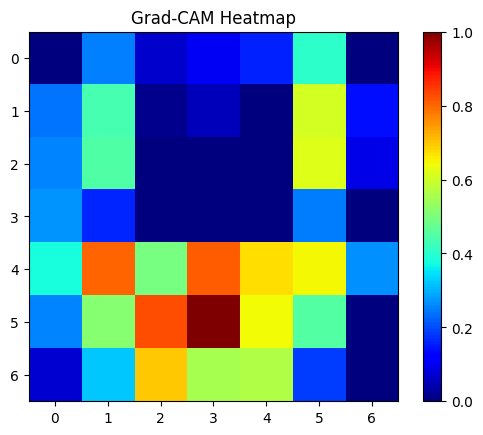

In [83]:
heatmap = make_gradcam_heatmap(img_array)

plt.imshow(heatmap, cmap="jet")

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.show()

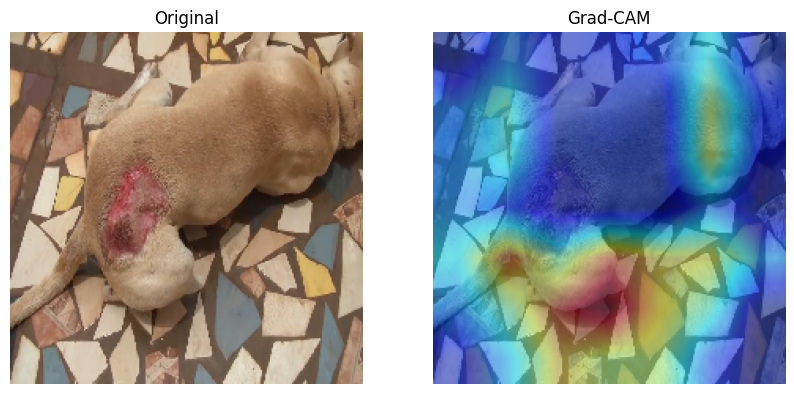

In [84]:
heatmap = cv2.resize(heatmap, (224,224))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

original = (img*255).astype("uint8")

overlay = cv2.addWeighted(original,0.6,heatmap,0.4,0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(original)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))

plt.title("Grad-CAM")

plt.axis("off")

plt.show()

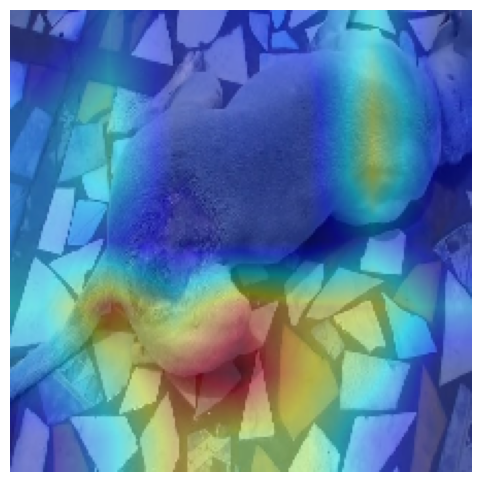

In [85]:
plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.savefig(
    "gradcam_result.png",
    dpi=300,
    bbox_inches="tight"
)

In [86]:
!pip install shap

In [87]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [88]:
background_images, _ = next(train_data)

background = background_images[:50]

In [89]:
test_images, test_labels = next(test_data)

test_sample = test_images[:5]

In [90]:
explainer = shap.DeepExplainer(
    mobilenet_model,
    background
)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_182
Received: inputs=['Tensor(shape=(32, 224, 224, 3))']
  warnings.warn(msg)


In [93]:
import shap

# Background images
background_images, _ = next(train_data)
background = background_images[:20]

# Test images
test_images, _ = next(test_data)
test_sample = test_images[:5]

masker = shap.maskers.Image("blur(32,32)", test_sample[0].shape)

explainer = shap.Explainer(
    mobilenet_model,
    masker
)

shap_values = explainer(test_sample)

shap.image_plot(shap_values)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  20%|██        | 1/5 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 3/5 [00:46<00:21, 10.67s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 5/5 [01:28<00:00, 17.33s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [01:49, 21.91s/it]                       


ValueError: cannot reshape array of size 1 into shape (6)

In [96]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [103]:
# Gaussian Noise
def add_noise(image):
    noise = np.random.normal(0, 0.08, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 1)

# Gaussian Blur
def add_blur(image):
    return cv2.GaussianBlur(image, (7,7), 0)

# Brightness Increase
def increase_brightness(image):
    bright = image * 1.3
    return np.clip(bright, 0, 1)

# Brightness Decrease
def decrease_brightness(image):
    dark = image * 0.6
    return np.clip(dark, 0, 1)

# Rotation
def rotate_image(image):
    M = cv2.getRotationMatrix2D((112,112),15,1)
    return cv2.warpAffine(image,M,(224,224))

# Occlusion
def occlude(image):
    img = image.copy()
    img[70:150,70:150,:] = 0
    return img

In [108]:
def predict_accuracy(images, labels):

    preds = mobilenet_model.predict(images, verbose=0)

    y_pred = np.argmax(preds, axis=1)

    y_true = np.argmax(labels, axis=1)

    acc = np.mean(y_pred == y_true)

    return acc

In [109]:
images, labels = next(test_data)

print(images.shape)

(32, 224, 224, 3)


In [111]:
results = []

# Original
results.append([
    "Original",
    predict_accuracy(images,labels)
])

# Noise
noise_imgs = np.array([add_noise(i) for i in images])

results.append([
    "Gaussian Noise",
    predict_accuracy(noise_imgs,labels)
])

# Blur
blur_imgs = np.array([add_blur(i) for i in images])

results.append([
    "Gaussian Blur",
    predict_accuracy(blur_imgs,labels)
])

# Brightness +
bright_imgs = np.array([increase_brightness(i) for i in images])

results.append([
    "Brightness +",
    predict_accuracy(bright_imgs,labels)
])

# Brightness -
dark_imgs = np.array([decrease_brightness(i) for i in images])

results.append([
    "Brightness -",
    predict_accuracy(dark_imgs,labels)
])

# Rotation
rot_imgs = np.array([rotate_image(i) for i in images])

results.append([
    "Rotation",
    predict_accuracy(rot_imgs,labels)
])

# Occlusion
occ_imgs = np.array([occlude(i) for i in images])

results.append([
    "Occlusion",
    predict_accuracy(occ_imgs,labels)
])

In [112]:
robustness_df = pd.DataFrame(
    results,
    columns=[
        "Condition",
        "Accuracy"
    ]
)

print(robustness_df)

        Condition  Accuracy
0        Original   0.34375
1  Gaussian Noise   0.68750
2   Gaussian Blur   0.50000
3    Brightness +   0.37500
4    Brightness -   0.53125
5        Rotation   0.50000
6       Occlusion   0.90625


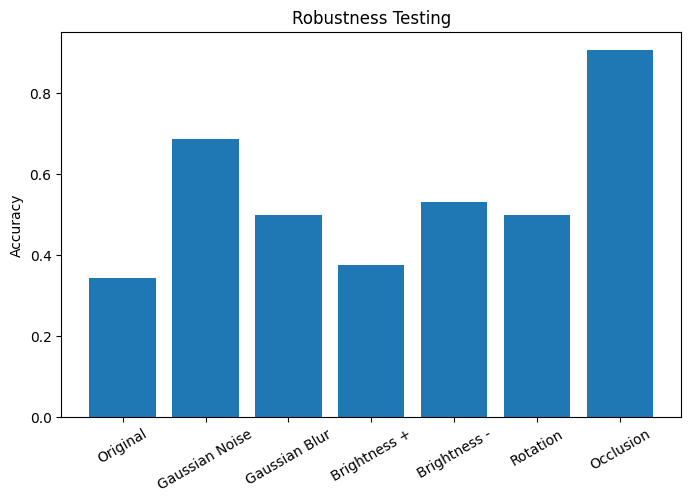

In [113]:
plt.figure(figsize=(8,5))

plt.bar(
    robustness_df["Condition"],
    robustness_df["Accuracy"]
)

plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.title("Robustness Testing")

plt.show()

In [115]:
plt.savefig(
    "robustness_testing.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [118]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Accuracy": [0.66, 0.76],
    "Weighted F1-score": [0.64, 0.74]
})

results

,Model,Accuracy,Weighted F1-score
0,Custom CNN,0.66,0.64
1,MobileNetV2,0.76,0.74


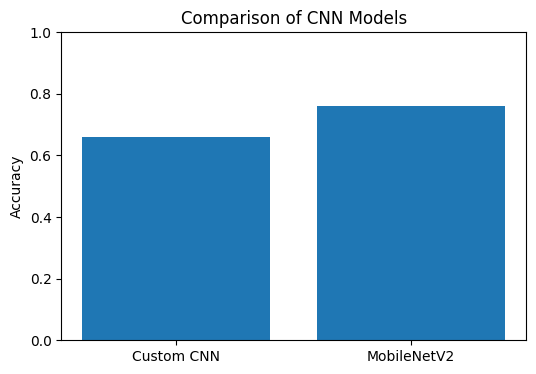

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["Accuracy"])

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Comparison of CNN Models")

plt.show()